### 5.2.4 种群拟蒙特卡洛

我们考虑贝叶斯计算问题,目标是从后验分布中获取样本$D=\{\boldsymbol{x}\}_{i=1}^n$:

$$f(\boldsymbol{x})=\frac{h(\boldsymbol{x})}{Z}$$

式中$h(\boldsymbol{x})$为未归一化后验密度(似然函数与先验分布的乘积),归一化常数$Z=\int h(\boldsymbol{x})d\boldsymbol{x}$.由于求解$Z$需要计算高维积分,通常采用马尔可夫链蒙特卡洛(MCMC)方法抽样,该类方法无需知晓$Z$.但MCMC样本之间存在相关性,需要大量样本才能收敛至目标分布.假设我们已经得到一组大规模样本$\{\boldsymbol{X}_i\}_{i=1}^N$.为降低存储开销与后续计算量,一般会采用抽稀方法削减样本数量.常用做法是在MCMC链中每隔$k$个样本选取一个(例如取$k=10$).显然,借助支撑点可以得到质量远优于普通抽稀的样本(马克,约瑟夫,2018b).但该方法需要先获取$N$个未归一化后验分布样本;若$h(\boldsymbol{x})$的求值成本很高,获取样本的代价有时会十分高昂.

假设$h(\boldsymbol{x})$的求值成本很高,因此我们无法得到大规模MCMC样本.在4.6.1节中,我们采用最小能量设计(MED)处理该问题.但与支撑点不同,最小能量设计无法保证得到最优规模为$n$的样本集.因此,使用支撑点能够对目标密度实现更好的近似.求解支撑点需要解如下优化问题:

$$\min_{D}\left(\frac{2}{n}\sum_{i=1}^n\int\|\boldsymbol{x}_i-\boldsymbol{X}\|\frac{h(\boldsymbol{X})}{Z}\mathrm{d}\boldsymbol{X}-\frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n\|\boldsymbol{x}_i-\boldsymbol{x}_j\|\right)$$

遗憾的是,归一化常数$Z$无法像最小能量设计的目标函数那样被分离提出,因此该优化问题难以直接求解.

假设我们能够从建议密度$q(\boldsymbol{X})$中抽取大量样本.此时上述优化问题可以改写为:

$$\min_{D}\left(\frac{2}{n}\sum_{i=1}^n\int\|\boldsymbol{x}_i-\boldsymbol{X}\|\frac{h(\boldsymbol{X})}{Zq(\boldsymbol{X})}q(\boldsymbol{X})\mathrm{d}\boldsymbol{X}-\frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n\|\boldsymbol{x}_i-\boldsymbol{x}_j\|\right)$$

其中

$$Z=\int h(\boldsymbol{X})\mathrm{d}\boldsymbol{X}=\int\frac{h(\boldsymbol{X})}{q(\boldsymbol{X})}q(\boldsymbol{X})\mathrm{d}\boldsymbol{X}$$

设$\boldsymbol{X}_1,\dots,\boldsymbol{X}_N\sim q(\boldsymbol{X})$,则我们可以求解下面的优化问题:

$$\min_{D}\left(\frac{2}{n}\sum_{i=1}^n\sum_{j=1}^N\|\boldsymbol{x}_i-\boldsymbol{X}_j\|w_j-\frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^n\|\boldsymbol{x}_i-\boldsymbol{x}_j\|\right)\tag{5.17}$$

其中权重$w_j$为重要性权重:

$$w_j=\frac{h(\boldsymbol{X}_j)/q(\boldsymbol{X}_j)}{\sum_{j=1}^Nh(\boldsymbol{X}_j)/q(\boldsymbol{X}_j)}$$

黄等人(2022)将式(5.17)求得的最优样本称为重要性支撑点(ISP).

尽管式(5.17)能够高效求解,但在高维空间构造合适的重要性抽样建议分布$q(\boldsymbol{X})$并不容易.为此,黄等人(2022)提出将该思路融入种群蒙特卡洛(PMC)框架(卡佩等人,2004).种群蒙特卡洛迭代执行三个步骤.算法初始拥有$K$个样本,我们在每个样本中心构造正态分布,得到$K$个建议分布$q_1(\boldsymbol{x}),\dots,q_K(\boldsymbol{x})$.第一步:抽样,从每一个建议分布抽取$J$个样本,总共得到$KJ$个样本.第二步:赋权,为全部样本计算重要性权重.第三步:自适应更新,基于$KJ$个样本与重要性权重重抽样,得到新的$K$个样本.该流程迭代执行$T$轮,完整流程见算法1.利用这些带权重样本,可以估计积分$I=\int h(\boldsymbol{x})f(\boldsymbol{x})d\boldsymbol{x}$:

$$\widehat{I}^{\text{PMC}}=\frac{1}{TKJ}\sum_{t=1}^T\sum_{k=1}^K\sum_{j=1}^Jw_{k,j}^{(t)}h(x_{k,j}^{(t)})/\widehat{Z}$$

其中$\widehat{Z}=\sum_{t=1}^T\sum_{k=1}^K\sum_{j=1}^Jw_{k,j}^{(t)}/TKJ$.

黄等人(2022)的核心思路是:在自适应更新阶段,使用式(5.17)的重要性支撑点重抽样.这$K$个支撑点可以更好表征全部$KJ$个样本,从而为新一轮建议分布提供更优质的中心.他们将改进后的算法命名为种群拟蒙特卡洛(PQMC).黄等人(2022)还针对抽样与赋权步骤提出多项改进方案,本文不再赘述细节.

> **算法1** 种群蒙特卡洛
> 
> **目标分布** $f=h/Z$,$Z$为未知归一化常数.
> 
> **初始化** 设置初始建议分布参数$\{q_k=\mathcal{N}(\cdot|\boldsymbol{\mu}_k,\Sigma)\}_{k=1}^K$.
> 
> 对$t=1,\dots,T$循环执行:
> 
> - **抽样** 对每个建议分布$k=1,\dots,K$抽取$J$个样本
> 
> $$x_{k,j}^{(t)}\sim q_k^{(t)},\;j=1,\dots,J,\;k=1,\dots,K$$
> 
> 总计生成$KJ$个样本.
> 
> - **赋权** 计算确定性混合权重
> 
> $$w_{k,j}^{(t)}=\frac{h(x_{k,j})^{(t)}}{K^{-1}\sum_{i=1}^Kq_i\left(x_{k,j}^{(t)}|\boldsymbol{\mu}_i^{(t)},\Sigma\right)},\;j=1,\dots,J,\;k=1,\dots,K$$
> 
> 并归一化:
> 
> $$\overline{w}_{k,j}^{(t)}=\frac{w_{k,j}^{(t)}}{\sum_{i=1}^K\sum_{l=1}^Jw_{i,l}^{(t)}}$$
> - **自适应更新** 执行重抽样更新建议分布中心
> 
> $$\boldsymbol{\mu}_k^{(t+1)}\stackrel{\text{i.i.d.}}{\sim}\sum_{k=1}^K\sum_{j=1}^J\overline{w}_{k,j}^{(t)}\delta_{x_{k,j}^{(t)}},\;k=1,\dots,K$$
> 
> **返回结果** $\{(x_{k,j}^{(t)},w_{k,j}^{(t)})\}_{t=1}^{T}{}_{k=1}^{K}{}_{j=1}^{J}$,其中$w_{k,j}^{(t)}$为未归一化权重.

举一个算例,考虑下面混合正态分布:

$$f(x)=\frac{1}{5}\sum_{i=1}^5\mathcal{N}(\boldsymbol{x};\boldsymbol{\mu}_i,\boldsymbol{\Sigma}_i)$$

其中$\boldsymbol{\mu}_1=(0.250,0.250)'$,$\boldsymbol{\mu}_2=(0.500,0.900)'$,$\boldsymbol{\mu}_3=(0.825,0.700)'$,$\boldsymbol{\mu}_4=(0.275,0.675)'$,$\boldsymbol{\mu}_5=(0.850,0.150)'$;$\boldsymbol{\Sigma}_1=40^{-2}\begin{bmatrix}2&0.6\\0.6&1\end{bmatrix}$,$\boldsymbol{\Sigma}_2=40^{-2}\begin{bmatrix}2&-0.4\\-0.4&2\end{bmatrix}$,$\boldsymbol{\Sigma}_3=40^{-2}\begin{bmatrix}2&0.8\\0.8&2\end{bmatrix}$,$\boldsymbol{\Sigma}_4=40^{-2}\begin{bmatrix}3&0\\0&0.5\end{bmatrix}$,$\boldsymbol{\Sigma}_5=40^{-2}\begin{bmatrix}2&-0.1\\-0.1&2\end{bmatrix}$.取参数$K=20,\;J=10,\;T=4$,该设置下总计需要800次密度求值.图5.9展示了种群蒙特卡洛(采用多项重抽样)与种群拟蒙特卡洛的样本以及最终重抽样得到的分布中心.可以看出,相比种群蒙特卡洛,种群拟蒙特卡洛的样本与建议分布中心能够很好地落在高密度区域.因此种群拟蒙特卡洛可以生成质量高得多的带权重样本.

> **图5.9** 混合正态算例下种群蒙特卡洛(左图)与种群拟蒙特卡洛(右图)得到的800个样本(红色叉号)及最终建议分布中心点集(蓝色实心圆点)

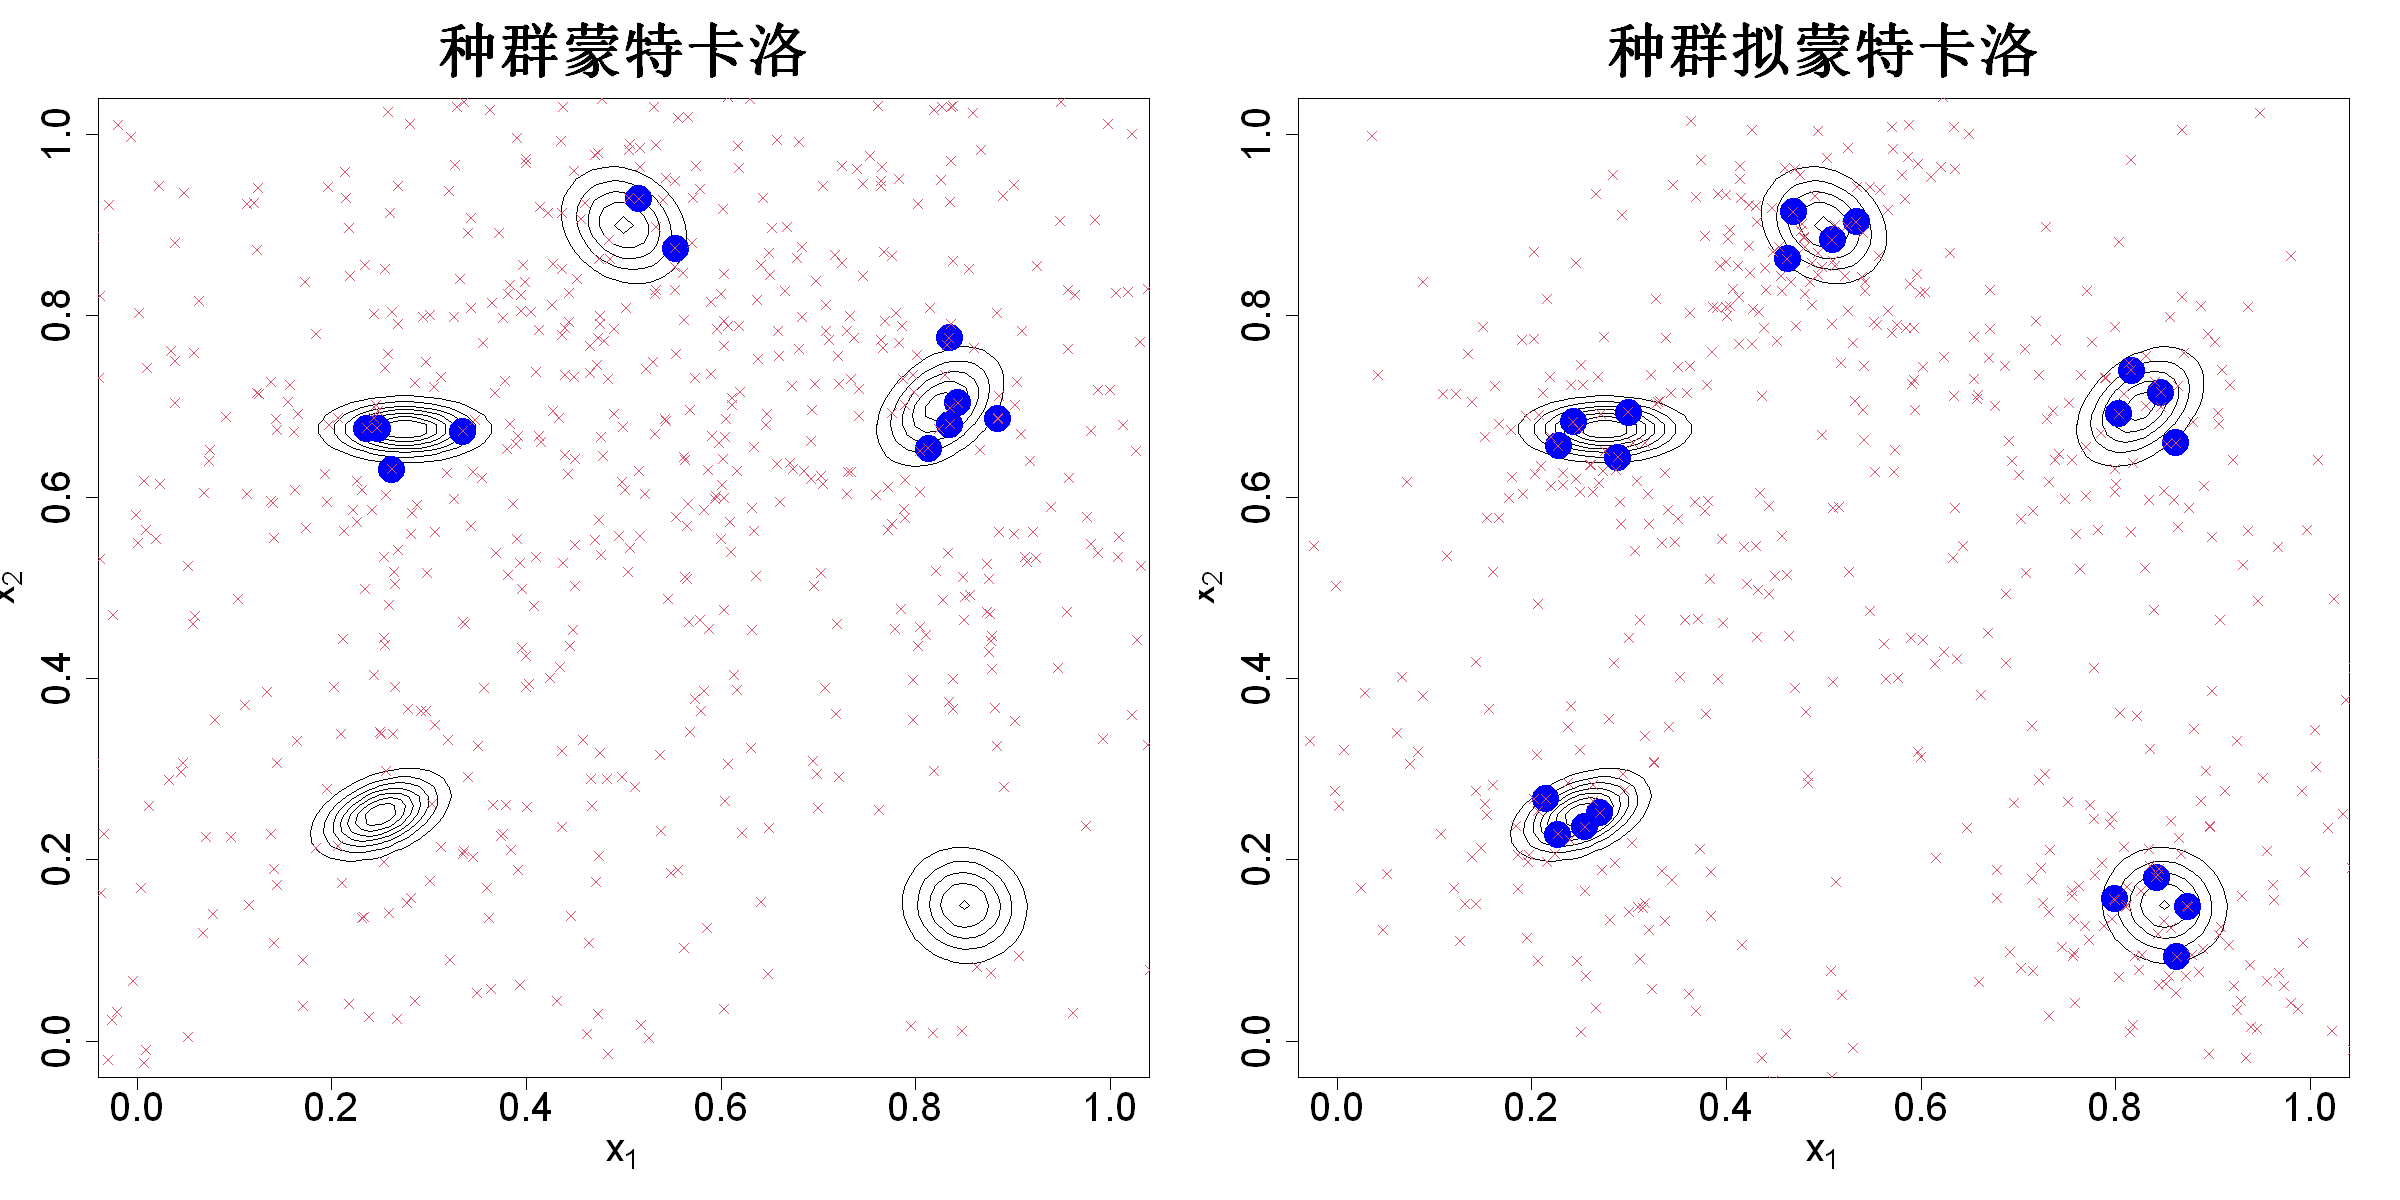

In [ ]:
#图5.9

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
library(mvtnorm)
library(pmc)
logmixture=function(x){
  v=matrix(NA,nrow=5,ncol=2)
  v[1,]=c(-10,-10)
  v[2,]=c(0,16)
  v[3,]=c(13,8)
  v[4,]=c(-9,7)
  v[5,]=c(14,-14)
  v=(v+20)/40
  sigma=array(NA,dim=c(5,2,2))
  sigma[1,,]=matrix(c(2,0.6,0.6,1),nrow=2)/40^2
  sigma[2,,]=matrix(c(2,-0.4,-0.4,2),nrow=2)/40^2
  sigma[3,,]=matrix(c(2,0.8,0.8,2),nrow=2)/40^2
  sigma[4,,]=matrix(c(3,0,0,0.5),nrow=2)/40^2
  sigma[5,,]=matrix(c(2,-0.1,-0.1,2),nrow=2)/40^2
  logf=rep(0,5)
  for(i in 1:5)logf[i]=dmvnorm(x,mean=v[i,],sigma=sigma[i,,],log=TRUE)
  logaddexp(logf)-log(5)
}
x1=x2=seq(0,1,length=101)
x.grid=expand.grid(x1,x2)
density=matrix(exp(apply(x.grid,1,logmixture)),nrow=101,ncol=101)

set.seed(1)
Z=1;p=2;K=20;J=10;steps=4;sigma_init=0.2
ini=matrix(runif(K*p),ncol=p)
pmc.mn=pmc(logmixture,K,J,steps,ini,sampling="random",resampling="multinomial",sigma=sigma_init,sigma.adapt=FALSE)
contour.default(x=x1,y=x2,z=density,drawlabels=FALSE,nlevels=10,main="种群蒙特卡洛",cex.main=3,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
points(pmc.mn$center.all[(K*steps+1):(K*steps+K),],col="blue",pch=16,cex=3)
points(pmc.mn$samp.all,col=2,pch=4,cex=1)

pqmc.isp=pmc(logmixture,K,J,steps,ini,sampling="qmc",resampling="sp",sigma=sigma_init,sigma.adapt=TRUE)
contour.default(x=x1,y=x2,z=density,drawlabels=FALSE,nlevels=10,main="种群拟蒙特卡洛",cex.main=3,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
points(pqmc.isp$center.all[(K*steps+1):(K*steps+K),],col="blue",pch=16,cex=3)
points(pqmc.isp$samp.all,col=2,pch=4,cex=1)
par(mfrow=c(1,1))